In [1]:
import os
os.environ["PATH"] = os.path.expanduser("~/texlive/bin/x86_64-linux") + ":" + os.environ["PATH"]

import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
import scienceplots
from h5py import File
from tqdm import trange
from astropy.cosmology import FlatLambdaCDM

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_rusty)

/mnt/home/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_random_MAH(log_mass_min=None, log_mass_max=None):
    mass = []
    for nstep in trange(100):
        fname = f"/mnt/home/rstiskalek/ceph/CSiBORG/postprocessing/MAH/RANDOM_N512_L300/step_{nstep}.hdf5"
        # fname = f"/mnt/home/rstiskalek/ceph/CSiBORG/postprocessing/MAH/RANDOM_N1024_L1000/step_{nstep}.hdf5"
        with File(fname, "r") as f:
            mass_i = f["mass"][...]
            redshift_i = f["redshift"][0, ...]

        mass.append(mass_i)
    
    mass = np.concatenate(mass)

    if log_mass_min is not None:
        m = mass[:, 0] > 10**log_mass_min
        mass = mass[m]
    
    if log_mass_max is not None:
        m = mass[:, 0] < 10**log_mass_max
        mass = mass[m]

    return redshift_i, mass


def load_constrained(which_cluster="Coma"):
    nsim = 50

    dist = np.full(nsim, np.nan)
    mass = np.full((nsim, 131), np.nan)
    redshift = np.full((nsim, 131), np.nan)

    for nstep in trange(nsim):
        fname = f"/mnt/home/rstiskalek/ceph/CSiBORG/postprocessing/MAH/2MPP_MULTIBIN_N256_DES_V2/step_{nstep}.hdf5"

        with File(fname, 'r') as f:
            root_pos = f["root_pos"][...]
            mass_i = f["mass"][...]
            redshift_i = f["redshift"][...]
    
        root_pos = root_pos[:, [2, 1, 0]]
    
        if which_cluster == "Coma":
            ref_pos = np.asarray([278.72046, 324.3668 , 374.4839 ])
        elif which_cluster == "Virgo":
            ref_pos = np.asarray([326.31216, 338.061  , 343.4548 ])
        else:
            raise ValueError(f"Unknown cluster `{which_cluster}`.")
    
        dist_i = np.linalg.norm(root_pos - ref_pos, axis=1)
        k = np.argmin(dist_i)

        dist[nstep] = dist_i[k]
        mass[nstep] = mass_i[k]
        redshift[nstep] = redshift_i[k]
        
    return mass, redshift, dist

    
    
    

100%|██████████| 50/50 [00:00<00:00, 189.89it/s]


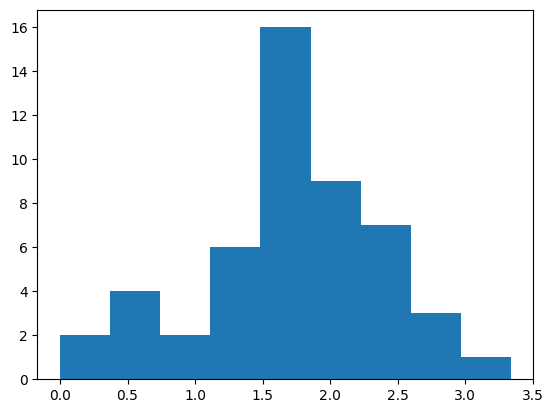

In [31]:
mass, redshift, dist = load_constrained("Virgo")


plt.figure()
plt.hist(dist, bins="auto")
plt.show()



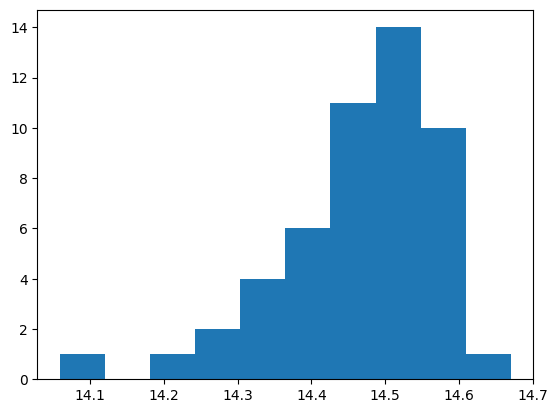

In [32]:
plt.figure()
plt.hist(np.log10(mass[:, 0]), bins="auto")

plt.show()

In [33]:
z_rand, mass_rand_all = load_random_MAH(14.1, 14.7)
len(mass_rand_all)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 211.24it/s]


44536

In [34]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def greedy_k_unique_nn_indices(log_mass0, log_mass0_rand, k=5):
    log_mass0 = np.asarray(log_mass0).reshape(-1, 1)
    log_mass0_rand = np.asarray(log_mass0_rand).reshape(-1, 1)

    n_target = len(log_mass0)
    n_total_needed = n_target * k

    if len(log_mass0_rand) < n_total_needed:
        raise ValueError(f"Not enough samples in log_mass0_rand ({len(log_mass0_rand)}), need at least {n_total_needed}.")

    # Fit NN search
    nbrs = NearestNeighbors(n_neighbors=len(log_mass0_rand), algorithm='auto').fit(log_mass0_rand)
    distances, indices = nbrs.kneighbors(log_mass0)

    used = set()
    matches = []

    for i in range(n_target):
        chosen = []
        for idx in indices[i]:
            if idx not in used:
                used.add(idx)
                chosen.append(idx)  # Store index, not value
                if len(chosen) == k:
                    break
        if len(chosen) < k:
            raise RuntimeError(f"Could not find {k} unique neighbors for sample {i}.")
        matches.append(chosen)

    return np.array(matches).reshape(-1,)  # shape: (n_target * k,)



In [35]:
log_mass0 = np.log10(mass[:, 0])
log_mass0_rand = np.log10(mass_rand_all[:, 0])

ks = greedy_k_unique_nn_indices(log_mass0, log_mass0_rand, k=10)
mass_rand = mass_rand_all[ks]

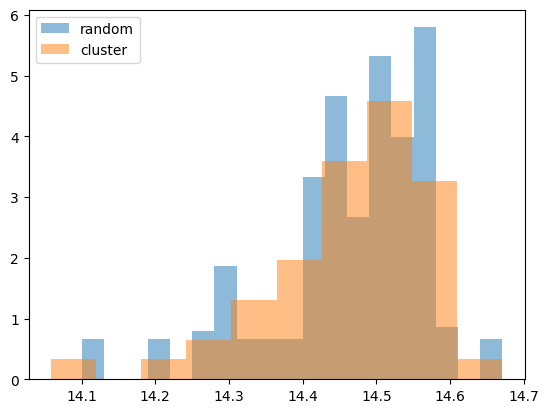

In [36]:
plt.figure()
plt.hist(np.log10(mass_rand[:, 0]), bins="auto", alpha=0.5, label="random", density=True)
plt.hist(np.log10(mass[:, 0]), bins="auto", alpha=0.5, label="cluster", density=True)
plt.legend()
plt.show()

/mnt/home/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/mnt/home/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/astropy/cosmology/flrw/lambdacdm.py:494: RuntimeWarning: invalid value encountered in divide
  np.emath.sqrt((1 / self.Om0 - 1 + 0j) / (aszarr(z) + 1.0) ** 3)
/tmp/ipykernel_2398185/2497483895.py:26: RuntimeWarning: Mean of empty slice
  x = np.nanmean(redshift, axis=0)


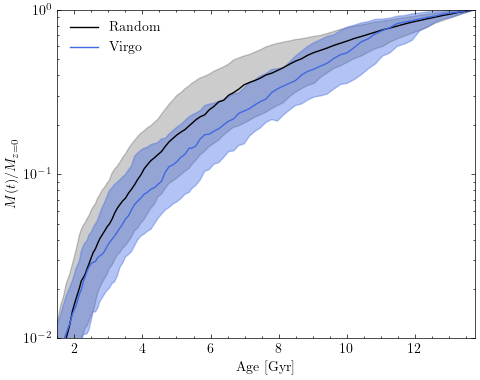

In [38]:
from scipy.signal import savgol_filter

cosmo = FlatLambdaCDM(H0=68.11, Om0=0.306,)
norm_mass = True

with plt.style.context("science"):
    plt.figure(figsize=(5, 4))

    if norm_mass:
        y = mass_rand / mass_rand[:, 0][:, None]
    else:
        y = mass_rand
    ylow, ymed, yhigh = np.nanpercentile(y, [16, 50, 84], axis=0)
    m = z_rand < 10
    x = cosmo.age(z_rand).value
    x, ylow, ymed, yhigh = x[m], ylow[m], ymed[m], yhigh[m]

    plt.plot(x, ymed, label="Random", color="k")
    plt.fill_between(x, ylow, yhigh, alpha=0.2, color="k")

    if norm_mass:
        y = mass / mass[:, 0][:, None]
    else:
        y = mass
    ylow, ymed, yhigh = np.nanpercentile(y, [16, 50, 84], axis=0)
    x = np.nanmean(redshift, axis=0)
    m = x < 10
    x = x[m]
    ylow, ymed, yhigh = ylow[m], ymed[m], yhigh[m]
    # ylow = savgol_filter(ylow, 6, 3)
    # ymed = savgol_filter(ymed, 6, 3)
    # yhigh = savgol_filter(yhigh, 6, 3)

    x = cosmo.age(x).value
    plt.plot(x, ymed, label="Virgo", color="royalblue")
    # for n in range(50):
    #     plt.plot(x, y[n, :][m], color="red",)
    # plt.plot(x, y[10, :][m], color="red",)
    # plt.plot(x, y[0, :][m], color="green",)
    plt.fill_between(x, ylow, yhigh, alpha=0.4, color="royalblue")



    plt.xlabel(r"$\mathrm{Age} ~ [\mathrm{Gyr}]$")
    plt.ylabel(r"$M(t) / M_{z = 0}$")


    plt.legend()
    plt.xlim(1.5, cosmo.age(0).value)
    plt.ylim(0.01, 1)
    # plt.ylim(1e13)
    # plt.xscale("log")
    plt.yscale("log")
    plt.tight_layout()
    plt.savefig("MAH_Virgo_random.png", bbox_inches="tight", dpi=450)

    plt.show()

In [23]:
z[4]

array([-4.44089210e-16,  1.67341579e-02,  3.37483478e-02,  5.10472558e-02,
        6.86356465e-02,  8.65183642e-02,  1.04700334e-01,  1.23186564e-01,
        1.41982145e-01,  1.61092255e-01,  1.80522156e-01,  2.00277200e-01,
        2.20362828e-01,  2.40784572e-01,  2.61548057e-01,  2.82659001e-01,
        3.04123220e-01,  3.25946623e-01,  3.48135224e-01,  3.70695131e-01,
        3.93632560e-01,  4.16953827e-01,  4.40665356e-01,  4.64773678e-01,
        4.89285432e-01,  5.14207369e-01,  5.39546354e-01,  5.65309366e-01,
        5.91503500e-01,  6.18135971e-01,  6.45214114e-01,  6.72745387e-01,
        7.00737372e-01,  7.29197780e-01,  7.58134448e-01,  7.87555348e-01,
        8.17468581e-01,  8.47882387e-01,  8.78805143e-01,  9.10245365e-01,
        9.42211712e-01,  9.74712990e-01,  1.00775815e+00,  1.04135629e+00,
        1.07551667e+00,  1.11024869e+00,  1.12783205e+00,  1.16343953e+00,
        1.19964287e+00,  1.23645204e+00,  1.27387718e+00,  1.31192860e+00,
        1.35061678e+00,  

In [13]:
np.vstack(M).shape

(2006, 131)